In [1]:
import numpy as np
from astropy.io import fits 
import matplotlib.pyplot as plt 
import astropy.constants as const
from tqdm import tqdm

import matplotlib
font = {'size'   : 18}

matplotlib.rc('font', **font)

#### Todo:

#### Average the part very far from the limb and substract to correct roughly for the stray light!

In [2]:
#susi_spec = fits.open("/home/milic/data/20240713_215257_15937007-20240713_215500_15954265-cam1_bin_1_1_1_full.fits")[0].data
#susi_spec = fits.open("/dat/milic/SUNRISE_III/SUSI/20240713_232802_16713289-20240714_001029_17071066-cam1_bin_1_1_10_full_3dExt_sff_order2.fits")
susi_spec = fits.open("/dat/milic/SUNRISE_III/SUSI/20240713_215257_15937007-20240713_215500_15954265-cam1_bin_1_1_1_full_3dExt.fits")
#susi_spec.info()

In [3]:
cube = np.zeros((240, 1556, 1912))
for i in tqdm(range(240)):
    cube[i,:,:] = np.copy(susi_spec[i].data[0,::-1,:])

100%|██████████| 240/240 [00:01<00:00, 131.57it/s]


In [4]:
# Get the wavelength array, as Francisco suggested: 

def susi_get_wl_axis(header):
    wl_par = np.array([header['MIN_WL_NM'], header['MIN_WL_PX'], header['MAX_WL_NM'], header['MAX_WL_PX']]).astype(
        np.float64
    )
    ax_size = header['NAXIS1']
    delta = (wl_par[2]-wl_par[0])/(wl_par[3] - wl_par[1])
    zero = wl_par[0] - delta
    wl_axis = np.linspace(zero, zero+delta*ax_size, ax_size)
    return wl_axis

In [5]:
# Note that this varies with time, slightly. Should not matter much for this paper:
ll = susi_get_wl_axis(susi_spec[0].header)

In [6]:
ll.shape
print(ll)
# Write it down as we need it for the other print
np.savetxt("susi_wavelength_axis.txt", ll.T)
print(np.gradient(ll))

[392.81418094 392.81520523 392.81622953 ... 394.76955946 394.77058375
 394.77160805]
[0.00102429 0.00102429 0.00102429 ... 0.00102429 0.00102429 0.00102429]


In [7]:
mean = np.mean(cube, axis=(0,1))
indexc = np.argmax(mean)
print(indexc)

1865


In [8]:
spectra_temporal_average = np.mean(cube, axis=0)

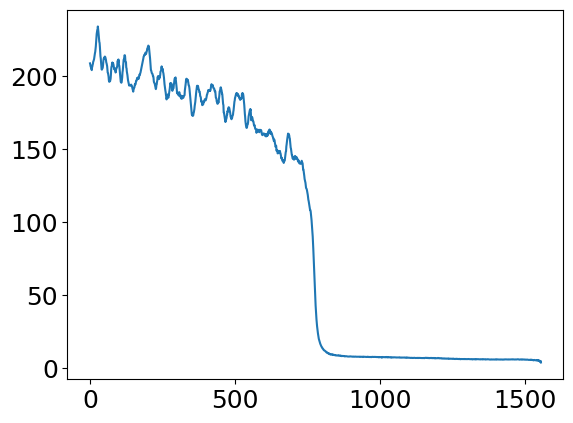

In [9]:
plt.plot(spectra_temporal_average[:,indexc])

### Let's try to look at the stray light

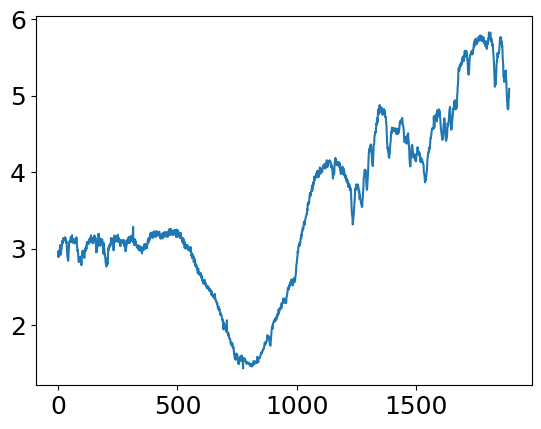

In [10]:
stray = np.mean(spectra_temporal_average[1400:1500],axis=0)
plt.plot(stray[10:-10])

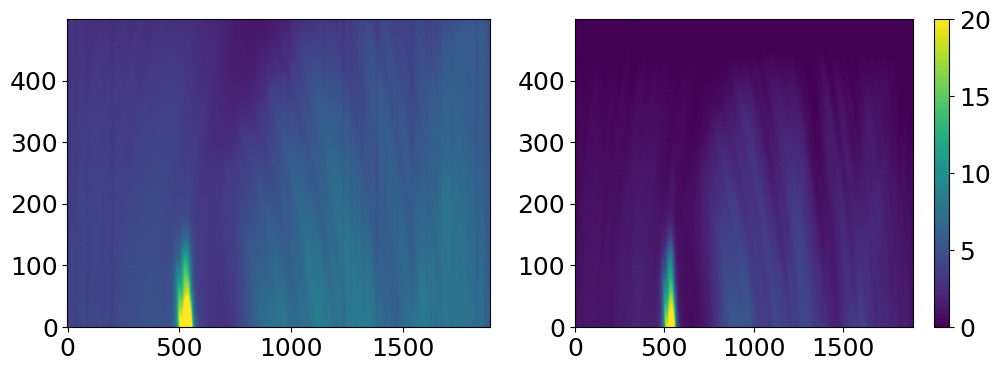

In [11]:
plt.figure(figsize=(12,4))
plt.subplot(121)
plt.imshow(spectra_temporal_average[1000:1500,10:-10], aspect='auto', origin='lower', vmin=0, vmax=20)
plt.subplot(122)
plt.imshow(spectra_temporal_average[1000:1500,10:-10]-stray[None,10:-10], aspect='auto', origin='lower', vmin=0, vmax=20)
plt.colorbar()

### Stray light looks quite low

### Now let's find the limb: 

In [12]:
# But llet''s subtract the stray light from the spectra and see what we get.
cube_corrected = cube - stray[None,None,:]


In [13]:
cube_corrected[cube_corrected < 0] = 1E-2

In [14]:
spectra_temporal_average = np.mean(cube_corrected, axis=0)

(20.0, 25.0)

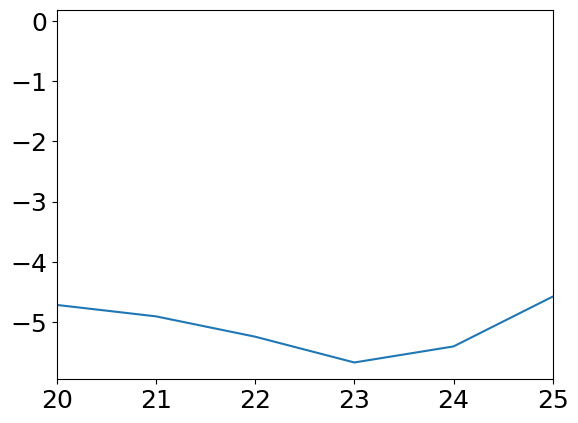

In [15]:
plt.plot(np.gradient(spectra_temporal_average[750:810,indexc]))
plt.xlim([20,25])

In [16]:
# LIMB IS ROUGHLY @ the index 773!!!
limblocation = 773

In [17]:
NX = spectra_temporal_average.shape[0]
print (NX)
limbdistances = (np.arange(NX) - limblocation)*19.25
print (limbdistances)

1556
[-14880.25 -14861.   -14841.75 ...  15015.    15034.25  15053.5 ]


In [18]:
# Save the limb distances for later use:
np.savetxt("susi_limb_distances.txt", limbdistances.T)

In [19]:
# Now we need a normalization which is going to be the flat field: 
ff = fits.open("/dat/milic/SUNRISE_III/SUSI/amended_corrected_frame.fits")
ff.info()

Filename: /dat/milic/SUNRISE_III/SUSI/amended_corrected_frame.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      31   (1912, 1565, 1)   float32   
  1                1 ImageHDU        13   (1910,)   float64   


In [20]:
ff_spectrum = ff[0].data[0,:,:]
ff_spectrum.shape

(1565, 1912)

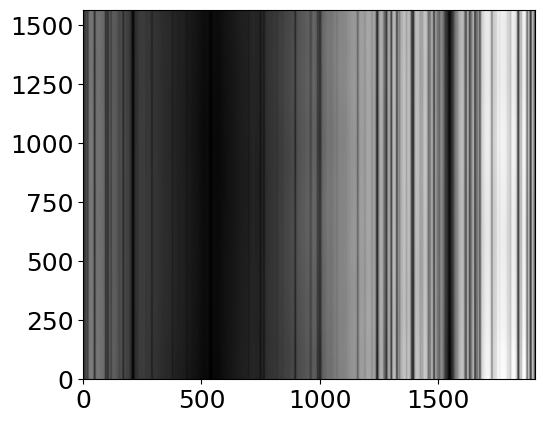

In [21]:
plt.imshow(ff_spectrum, origin='lower',cmap='gray')

In [22]:
ff_spectrum_mean = np.mean(ff_spectrum, axis=0)

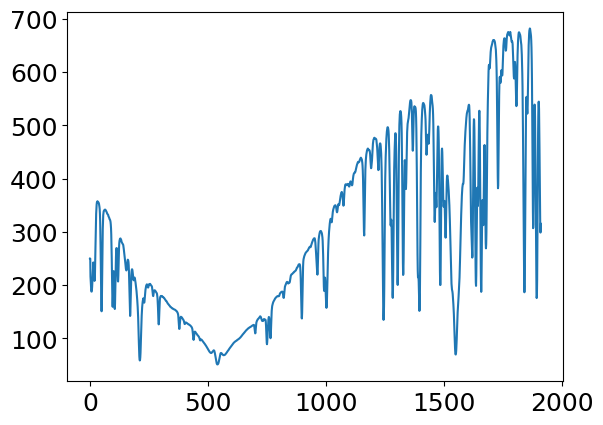

In [23]:
plt.plot(ff_spectrum_mean)

In [24]:
Iqs = ff_spectrum_mean[indexc]
print(Iqs)

680.9378


In [25]:
print (ll[indexc])

394.72449049246336


In [26]:
cube_corrected /= Iqs
spectra_temporal_average /= Iqs

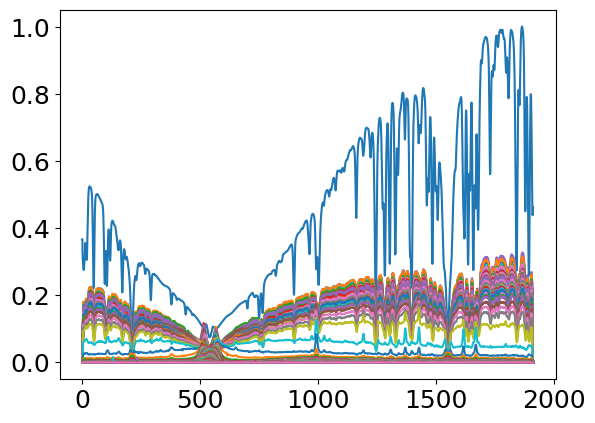

In [ ]:
# Check normalization
plt.plot(ff_spectrum_mean/ff_spectrum_mean[indexc])
for i in range(0,spectra_temporal_average.shape[0],10):
    plt.plot(spectra_temporal_average[i])

1033


(-0.005, 0.005)

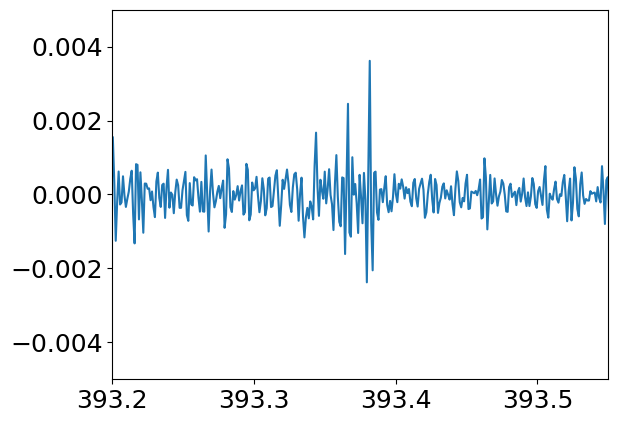

In [ ]:
# Look for blips:

testi = np.argmin(np.abs(limbdistances - 5000.0))
print(testi)

plt.plot(ll,np.gradient(np.gradient(cube_corrected[122,testi,:])))
plt.xlim([393.2, 393.55])
plt.ylim([-0.005,0.005])

In [58]:
# Go time by time, slit position by slit position and check for the blips in wavelength direction:
# import a median filter:
from scipy.ndimage import median_filter

for i in tqdm(range(cube_corrected.shape[0])):
    for j in range(cube_corrected.shape[1]):
        # Now we have to detect the blips in wavelength direction. We can do this by looking at the gradient of the spectrum and checking for outliers:
        spectrum = cube_corrected[i,j,:]
        grad2 = np.gradient(np.gradient(spectrum))
        outliers = np.where(np.abs(grad2) > 0.001)
        spectrum[outliers] = median_filter(spectrum, size=3)[outliers]



100%|██████████| 240/240 [00:42<00:00,  5.68it/s]


In [59]:
spectra_temporal_average = np.mean(cube_corrected, axis=0)

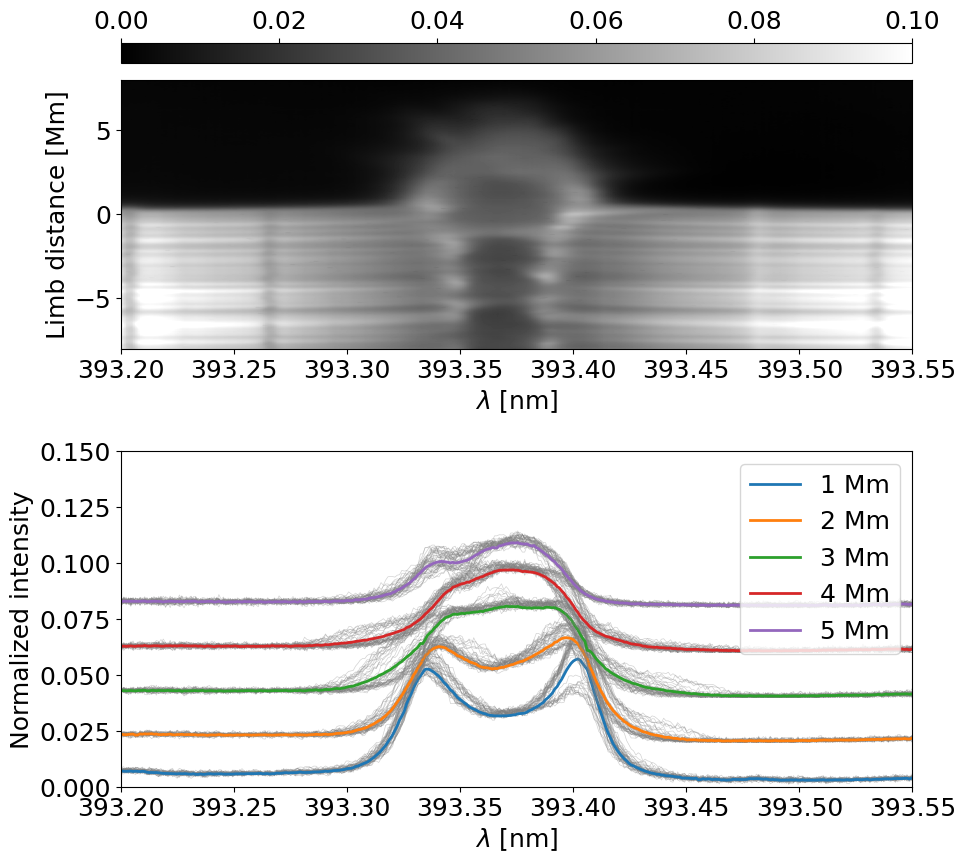

In [60]:
plt.figure(figsize=[10,9])
plt.subplot(211)
plt.imshow(spectra_temporal_average, origin='lower', extent=[ll[0],ll[-1], limbdistances[0]/1e3, limbdistances[-1]/1e3], aspect='auto', vmin=0.00, vmax=0.1, cmap='gray')
plt.ylim([-8,8])
plt.xlim([393.2, 393.55])
#plt.ylim([0,6000])
plt.xlabel("$\\lambda$ [nm]")
plt.ylabel("Limb distance [Mm]")

# How to move this colorbar on top:
plt.colorbar(orientation='horizontal', location='top',aspect=40)

plt.subplot(212)
for i in range(1000,6000,1000):
    # find index of the limb location:
    index = np.argmin(np.abs(limbdistances - i))
    
    # Now overplot some time dependent spectra to make this nicer: 
    for t in range(0, cube_corrected.shape[0]-10, 5):
        plt.plot(ll, cube_corrected[t,index,:]+0.02*(i/1000-1), linewidth=0.5, alpha=0.35, color='gray')

    plt.plot(ll, spectra_temporal_average[index]+0.02*(i/1000-1), linewidth=2,label=f'{int(i/1000)} Mm')
# position the legend in the top right
plt.legend(loc='upper right')
plt.xlim([393.2, 393.55])
plt.ylim([0,0.15])
plt.xlabel("$\\lambda$ [nm]")
plt.ylabel("Normalized intensity")
#plt.colorbar()


plt.tight_layout()
plt.savefig("figs/mean_limb_spectrum_plot.png", bbox_inches='tight')
plt.savefig("figs/mean_limb_spectrum_plot.pdf", bbox_inches='tight')

In [33]:
# After we are sure that the corrected data looks good, let's save it to a fits file for later use:
hdu = fits.PrimaryHDU(cube_corrected)
hdu.writeto("/dat/milic/SUSI_modeling/20240713_215257_15937007-20240713_215500_15954265-cam1_bin_1_1_1_full_3dExt_corrected.fits", overwrite=True)

39


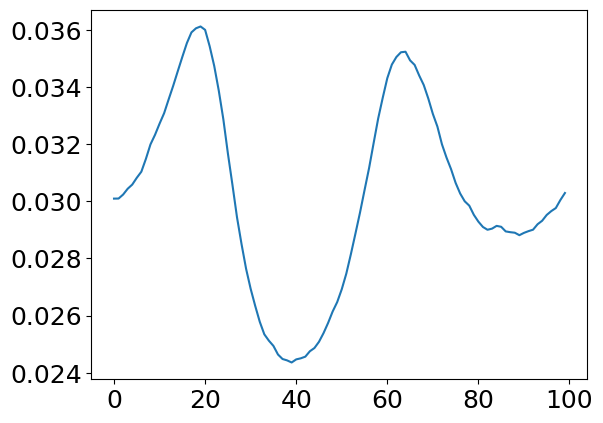

In [61]:
# First determine where is the line core in the average spectrum of everything:
indexcore = np.argmin(np.mean(spectra_temporal_average, axis=0)[500:600])   
print(indexcore)
plt.plot(np.mean(spectra_temporal_average, axis=0)[500:600])

In [35]:
ll_core = ll[indexcore+500]

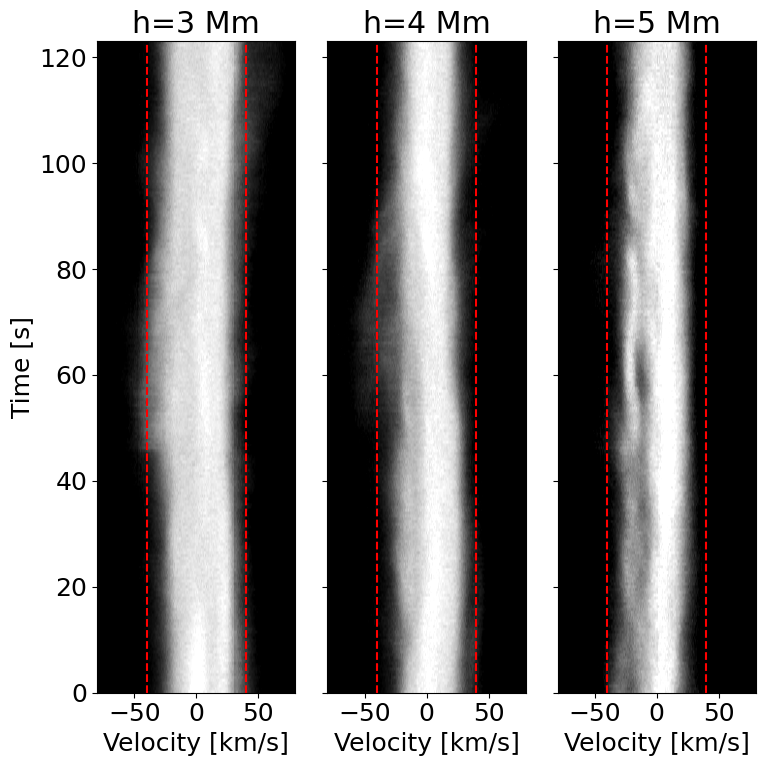

In [ ]:
# Let's do the plot above a bit more nicely with more tight x spacing, no colorbar and no ticks on the y axis except on the first one 
# Define velocity:
velocity = (ll - ll_core)/ll_core * const.c.to('km/s').value
vref = 50

fig, axs = plt.subplots(1,3, figsize=[8,8], sharex=True)
height = 3000.0
axs[0].imshow(cube_corrected[:-10,limblocation+int(height/19.25),:], aspect='auto', extent=[velocity.min(), velocity.max(), 0, 123], cmap='gray',vmin=0.005,vmax=0.045, origin='lower')
axs[0].set_xlabel("Velocity [km/s]")
axs[0].set_ylabel("Time [s]")
axs[0].set_xlim([-80,80])
# Overplot a vertical line at velocities of -/+ vref km/s
axs[0].axvline(-vref, color='red', linestyle='--')
axs[0].axvline(vref, color='red', linestyle='--')
#axs[0].set_ylim([0, spectra_temporal_average.shape[0]])
#axs[0].set_yticks([0, spectra_temporal_average.shape[0]])
#axs[0].set_yticklabels(['0', '240'])
axs[0].set_title("h=3 Mm")
height = 4000.0
axs[1].imshow(cube_corrected[:-10,limblocation+int(height/19.25),:], aspect='auto', extent=[velocity.min(), velocity.max(), 0, 123], cmap='gray',vmin=0.005,vmax=0.04, origin='lower')
axs[1].set_xlabel("Velocity [km/s]")
#axs[1].set_ylabel("Intensity")
axs[1].set_xlim([-80,80])
axs[1].axvline(-vref, color='red', linestyle='--')
axs[1].axvline(vref, color='red', linestyle='--')

#axs[1].set_ylim([0, spectra_temporal_average.shape[0]])
#axs[1].set_yticks([0, spectra_temporal_average.shape[0]])
axs[1].set_yticklabels([])
axs[1].set_title("h=4 Mm")
height = 5000.0
axs[2].imshow(cube_corrected[:-10,limblocation+int(height/19.25),:], aspect='auto', extent=[velocity.min(), velocity.max(), 0, 123], cmap='gray',vmin=0.005,vmax=0.03, origin='lower')
axs[2].set_xlabel("Velocity [km/s]")
#axs[2].set_ylabel("Intensity")
axs[2].set_xlim([-80,80])
axs[2].axvline(-vref, color='red', linestyle='--')
axs[2].axvline(vref, color='red', linestyle='--')
#axs[2].set_ylim([0, spectra_temporal_average.shape[0]])
#axs[2].set_yticks([0, spectra_temporal_average.shape[0]])
axs[2].set_yticklabels([])
axs[2].set_title("h=5 Mm")    

plt.tight_layout()
plt.savefig("figs/velocity_time_variation_nice.png", bbox_inches='tight')
plt.savefig("figs/velocity_time_variation_nice.eps", bbox_inches='tight')

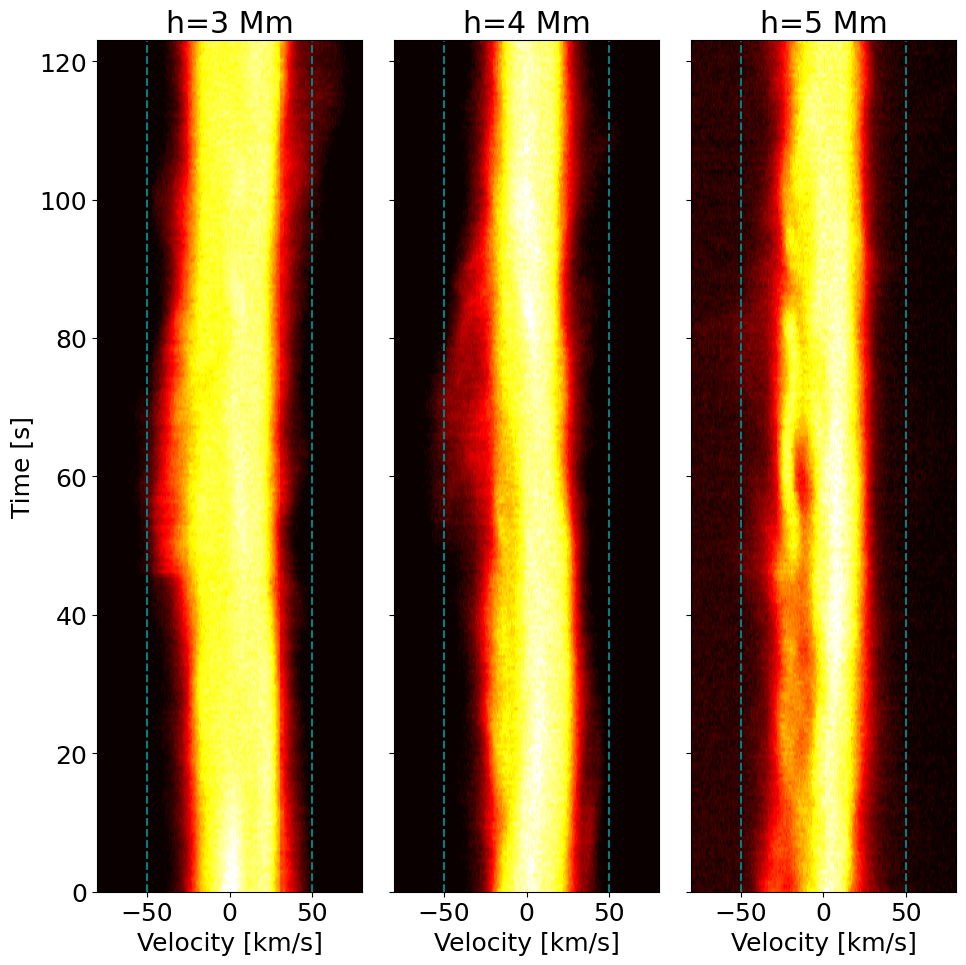

In [84]:
# Same as the above but with a color scale that goes from black to white for a given range and when from white to say, orange or red for the higher values. This is to show the low intensity features better.
# First I need a colormap that goes from black to white and then to red. I can use the matplotlib colormap "hot" for this. I will use the "hot" colormap and set the vmin and vmax to be the same as the previous plot.
fig, axs = plt.subplots(1,3, figsize=[10,10], sharex=True)
height = 3000.0
axs[0].imshow(cube_corrected[:-10,limblocation+int(height/19.25),:], aspect='auto', extent=[velocity.min(), velocity.max(), 0, 123], cmap='hot',vmin=0.005,vmax=0.048, origin='lower')
axs[0].set_xlabel("Velocity [km/s]")
axs[0].set_ylabel("Time [s]")
#fig.colorbar(axs[0].images[0], ax=axs[0], orientation='vertical', fraction=0.046, pad=0.04)
axs[0].set_xlim([-80,80])
# Overplot a vertical line at velocities of -/+ vref km/s
# Overlplot a few more vertical lines with more velocities above 50 km/s, say 60, 70, 80, 90, 100 km/s. These are to show the velocities of the features that we see in the spectra.
#for kk in range(40, 81, 10):
#    if (kk != 50):
#        axs[0].axvline(-kk, color='teal', linestyle='--', linewidth=1.0)
#        axs[0].axvline(kk, color='teal', linestyle='--', linewidth=1.0)
axs[0].axvline(-50, color='teal', linestyle='--')
axs[0].axvline(50, color='teal', linestyle='--')

#axs[0].set_ylim([0, spectra_temporal_average.shape[0]])
#axs[0].set_yticks([0, spectra_temporal_average.shape[0]])
#axs[0].set_yticklabels(['0', '240'])
axs[0].set_title("h=3 Mm")
height = 4000.0
axs[1].imshow(cube_corrected[:-10,limblocation+int(height/19.25),:], aspect='auto', extent=[velocity.min(), velocity.max(), 0, 123], cmap='hot',vmin=0.005,vmax=0.042, origin='lower')
axs[1].set_xlabel("Velocity [km/s]")
#axs[1].set_ylabel("Intensity")
axs[1].set_xlim([-80,80])
axs[1].axvline(-50, color='teal', linestyle='--')
axs[1].axvline(50, color='teal', linestyle='--')

#axs[1].set_ylim([0, spectra_temporal_average.shape[0]])
#axs[1].set_yticks([0, spectra_temporal_average.shape[0]])
axs[1].set_yticklabels([])
axs[1].set_title("h=4 Mm")
height = 5000.0
axs[2].imshow(cube_corrected[:-10,limblocation+int(height/19.25),:], aspect='auto', extent=[velocity.min(), velocity.max(), 0, 123], cmap='hot',vmin=0.001,vmax=0.033, origin='lower')
axs[2].set_xlabel("Velocity [km/s]")
#axs[2].set_ylabel("Intensity")
axs[2].set_xlim([-80,80])
axs[2].axvline(-50, color='teal', linestyle='--')
axs[2].axvline(50, color='teal', linestyle='--')
#axs[2].set_ylim([0, spectra_temporal_average.shape[0]])
#axs[2].set_yticks([0, spectra_temporal_average.shape[0]])
axs[2].set_yticklabels([])
axs[2].set_title("h=5 Mm")    

plt.tight_layout()
plt.savefig("figs/velocity_time_variation_color.png", bbox_inches='tight')
plt.savefig("figs/velocity_time_variation_color.eps", bbox_inches='tight')

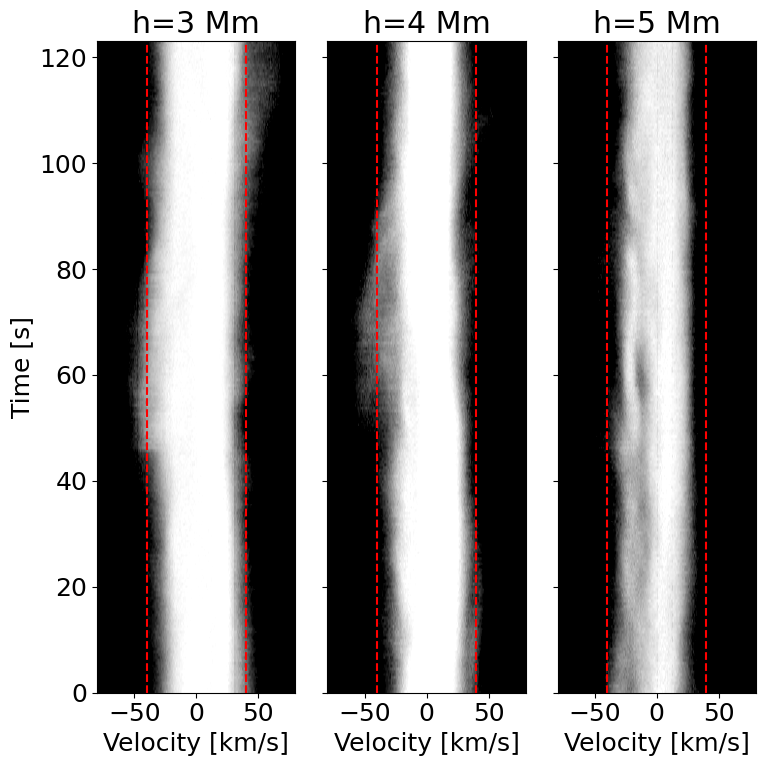

In [46]:
# Exactly like the above, but with the intensity in the log scale to see the fainter features better:

velocity = (ll - ll_core)/ll_core * const.c.to('km/s').value
vref = 40

fig, axs = plt.subplots(1,3, figsize=[8,8], sharex=True)
height = 3000.0
axs[0].imshow(np.log10(cube_corrected[:-10,limblocation+int(height/19.25),:]), aspect='auto', extent=[velocity.min(), velocity.max(), 0, 123], cmap='gray',vmin=-2.2,vmax=-1.4, origin='lower')
axs[0].set_xlabel("Velocity [km/s]")
axs[0].set_ylabel("Time [s]")
axs[0].set_xlim([-80,80])
# Overplot a vertical line at velocities of -/+ vref km/s
axs[0].axvline(-vref, color='red', linestyle='--')
axs[0].axvline(vref, color='red', linestyle='--')
#axs[0].set_ylim([0, spectra_temporal_average.shape[0]])
#axs[0].set_yticks([0, spectra_temporal_average.shape[0]])
#axs[0].set_yticklabels(['0', '240'])
axs[0].set_title("h=3 Mm")
height = 4000.0
axs[1].imshow(np.log10(cube_corrected[:-10,limblocation+int(height/19.25),:]), aspect='auto', extent=[velocity.min(), velocity.max(), 0, 123], cmap='gray',vmin=-2.2,vmax=-1.5, origin='lower')
axs[1].set_xlabel("Velocity [km/s]")
#axs[1].set_ylabel("Intensity")
axs[1].set_xlim([-80,80])
axs[1].axvline(-vref, color='red', linestyle='--')
axs[1].axvline(vref, color='red', linestyle='--')

#axs[1].set_ylim([0, spectra_temporal_average.shape[0]])
#axs[1].set_yticks([0, spectra_temporal_average.shape[0]])
axs[1].set_yticklabels([])
axs[1].set_title("h=4 Mm")
height = 5000.0
axs[2].imshow(np.log10(cube_corrected[:-10,limblocation+int(height/19.25),:]), aspect='auto', extent=[velocity.min(), velocity.max(), 0, 123], cmap='gray',vmin=-2.2,vmax=-1.5, origin='lower')
axs[2].set_xlabel("Velocity [km/s]")
#axs[2].set_ylabel("Intensity")
axs[2].set_xlim([-80,80])
axs[2].axvline(-vref, color='red', linestyle='--')
axs[2].axvline(vref, color='red', linestyle='--')
#axs[2].set_ylim([0, spectra_temporal_average.shape[0]])
#axs[2].set_yticks([0, spectra_temporal_average.shape[0]])
axs[2].set_yticklabels([])
axs[2].set_title("h=5 Mm")    

plt.tight_layout()
plt.savefig("figs/velocity_time_variation_nice_log.png", bbox_inches='tight')
plt.savefig("figs/velocity_time_variation_nice_log.eps", bbox_inches='tight')

In [ ]:
# Save the cube, normalized, with Stokes I only, in a separate fits to save for later:

hdu = fits.PrimaryHDU(cube)
hdu2 = fits.ImageHDU(ll)
hdu3 = fits.ImageHDU(limbdistances)
hdu4 = fits.ImageHDU(velocity)
hdulist = fits.HDUList([hdu, hdu2, hdu3, hdu4])
hdulist.writeto("/dat/milic/SUSI_modeling/susi_cube_202407132153_normalized.fits", overwrite=True)

In [ ]:
# Test the synthesis at the disk center:
synth_dc_falc = fits.open("/home/milic/codes/spherical1d/disk_center_test.fits")[0].data
print(synth_dc_falc.shape)

synth_dc_falc_susigrid = fits.open("/home/milic/codes/spherical1d/disk_center_susi.fits")[0].data
print(synth_dc_falc_susigrid.shape)

#synth_dc_muram = fits.open("/home/milic/codes/spherical1d/disk_center_test_muram.fits")[0].data
#print(synth_dc_muram.shape)


In [ ]:
plt.plot(synth_dc_falc, label='FALC')
#plt.plot(synth_dc_muram, label='MURaM')
plt.legend()

In [ ]:
# Now come the simulated spectra:
synth_spec = fits.open("~/codes/spherical1d/susi_synth_1d.fits")[0].data
synth_spec.shape
synth_spec = synth_spec[::-1,:]

### Find the limb For the simulations:

In [ ]:
#plt.plot(synth_spec[:,1865])
plt.plot(np.gradient(synth_spec[:,1865]))
#plt.xlim([680,690])

In [ ]:
index_limb_synth = 687

In [ ]:
synth_limbdistances = (np.arange(synth_spec.shape[0]) - index_limb_synth)*19.25

In [ ]:
synth_spec /= synth_dc_falc_susigrid[indexc]

In [ ]:
atlas = np.loadtxt("/home/milic/codes/spherical1d/atlas_bass_susilike.txt",unpack=True, skiprows=1, usecols=(0,1), delimiter=',')

In [ ]:
# sanity check
print(indexc)

In [ ]:
atlasindex = np.argmin(np.abs(atlas[0,:]/10 - ll[indexc]))
print(atlasindex)
print (atlas[0,atlasindex]/10, ll[indexc])

In [ ]:
plt.figure(figsize=[14,4])
plt.subplot(121)
plt.plot(ll,synth_dc_falc_susigrid/synth_dc_falc_susigrid[indexc], linewidth=3)
plt.plot(atlas[0]/10., atlas[1]/atlas[1][atlasindex], linewidth=3, label='Atlas')
for i in range(0,synth_spec.shape[0],10):
    plt.plot(ll,synth_spec[i,:])

plt.subplot(122)
plt.plot(ll,ff_spectrum_mean/ff_spectrum_mean[indexc], linewidth=3)
for i in range(0,spectra_temporal_average.shape[0],10):
    plt.plot(ll,spectra_temporal_average[i])


In [ ]:
plt.plot(ll,synth_dc_falc_susigrid)
np.min(synth_dc_falc_susigrid/synth_dc_falc_susigrid[indexc])

In [ ]:
plt.figure(figsize=[10,6.5])

# Make it a 

plt.subplot(211)
plt.imshow(spectra_temporal_average, origin='lower', extent=[ll[0],ll[-1], limbdistances[0]/1e3, limbdistances[-1]/1e3], aspect='auto', vmin=0.00, vmax=0.15, cmap='gray')
plt.ylim([-12,8])
plt.xlim([393.0, 393.8])
#plt.ylim([0,6000])
#plt.xlabel("$\\lambda$ [nm]")
plt.ylabel("Limb distance [Mm]")
plt.colorbar()

plt.subplot(212)
plt.imshow(synth_spec, origin='lower', extent=[ll[0],ll[-1], synth_limbdistances[0]/1e3, synth_limbdistances[-1]/1e3], aspect='auto', vmin=0.00, vmax=0.15, cmap='gray')
plt.ylim([-12,8])
plt.xlim([393.0, 393.8])
#plt.ylim([0,6000])
plt.xlabel("$\\lambda$ [nm]")
plt.ylabel("Limb distance [Mm]")
plt.colorbar()


plt.tight_layout()
plt.savefig("figs/mean_limb_spectrum_synth.png", bbox_inches='tight')
plt.savefig("figs/mean_limb_spectrum_synth.eps", bbox_inches='tight')

#### Now off limb modeling with 3D models

In [ ]:
path = "/dat/milic/SUSI_modeling/"

NS = 8
for i in range(0,NS):
    if (i==0):
        spectrum = fits.open(path+str(i)+"_test_off_limb_che_slit.fits")[0].data
        taus = fits.open(path+str(i)+"_test_off_limb_che_slit.fits")[1].data
        contrib = fits.open(path+str(i)+"_test_off_limb_che_slit.fits")[2].data
    else:
        spectrum = np.concatenate((spectrum, fits.open(path+str(i)+"_test_off_limb_che_slit.fits")[0].data), axis=0)
        taus = np.concatenate((taus, fits.open(path+str(i)+"_test_off_limb_che_slit.fits")[1].data), axis=0)
        contrib = np.concatenate((contrib, fits.open(path+str(i)+"_test_off_limb_che_slit.fits")[2].data), axis=0)

In [ ]:
spectrum = spectrum.reshape(NS,401, 601)
taus = taus.reshape(NS,401, 601)
contrib = contrib.reshape(NS,401, 601, 1024)

In [ ]:
wavelengths = np.linspace(393.06, 393.66, 601)
z = (np.arange(401)-49.0)*20.0
limbdistances_synth = z - 300.0


In [ ]:
opem = fits.open("/home/milic/codes/spherical1d/disk_center_test_opem.fits")[0].data
opemline = opem - opem[:,:,0][:,:,None]
Sline = opemline[1,:,947]/opemline[0,:,947]
print(Sline.shape)
#plt.semilogy(Sline)
# Need to extrapolate the above onto the same z grid as the off-limb slit, and then plot it together with the transmission to see if it makes sense.
# The idea is that the contribution to the emergent intensity from a given height should be roughly S(z)*(1-exp(-tau(z))).
S = np.ones(401)*Sline[-1]

In [ ]:
# Calculate and normalize 3Dspec

spec3D = (1.0 - np.exp(-taus[:,0:,:])) * S[None,:,None] / synth_dc_falc_susigrid[indexc]

In [ ]:
#z_falc = fits.open("/home/milic/codes/spherical1d/disk_center_test_opem.fits")[1].data
#print (z_falc/1E3)
#z_falc.shape
#plt.semilogy(z_falc/1E3, Sline)
# limit is where z is closest to 2Mm
#limit = np.argmin(np.abs(z_falc/1e3 - 2000.0))
#print(limit)
#limit = 80
# Hopefully z = 0 is the tau = 1 scale. That is #49 in the other one so let's go and try to extrapolate:

#S_extrapolated = np.interp(z, z_falc[:limit]/1E3, Sline[:limit])


In [ ]:
# Smoothe the S_extrapolated a bit in height
#from scipy.ndimage import gaussian_filter1d
#S_extrapolated = gaussian_filter1d(S_extrapolated, sigma=5)
#plt.semilogy(z, S_extrapolated)

In [ ]:
# Calculate and normalize 3Dspec

spec3D = (1.0 - np.exp(-taus[:,0:,:]))# * S_extrapolated[None,:,None] / synth_dc_falc_susigrid[indexc]

In [ ]:
# Now time to compare the two: 
# 2 subplots with the same x and y limits, one with the observed one with synthetic 3D:
i = 0
plt.figure(figsize=(10,12))
plt.subplot(211)
plt.imshow(spectra_temporal_average, origin='lower', extent=[ll[0],ll[-1], limbdistances[0], limbdistances[-1]], aspect='auto', vmin=0.00, vmax=0.05, cmap='gray')
plt.colorbar()
plt.xlim(wavelengths[0], wavelengths[-1])
plt.ylim(0,6500)
plt.ylabel("Height [km]")
plt.xlabel("Wavelength [nm]")
plt.title("Observed")
plt.subplot(212)
plt.imshow(spec3D[i]*0.05, origin='lower', aspect='auto',extent=[wavelengths[0],wavelengths[-1],limbdistances_synth[0],limbdistances_synth[-1]],vmin=0,vmax=0.05, cmap='gray')
plt.colorbar()
plt.xlim(wavelengths[0], wavelengths[-1])
plt.ylim(0,6500)
plt.ylabel("Height [km]")
plt.xlabel("Wavelength [nm]")
plt.title("Synthetic")
plt.tight_layout()
plt.savefig(str(i)+"comparison_off_limb_slit.png",bbox_inches='tight')
plt.savefig(str(i)+"comparison_off_limb_slit.eps",bbox_inches='tight')

In [ ]:
import muram as mio
# Read the simulated temperature: 
mcube = mio.MuramSnap("/dat/milic/MURaM_enhanced_network/",499000)
mcube.Temp.shape
Temp = mcube.Temp.transpose(1,2,0)

z_to_plot = 49 + int(2000.0 / 20.0)

In [ ]:
# We also need to calculate where are the +50 km/s in the synthetic spectra to overplot them on the observed ones. Let's do that quickly:
indexcore = 539
velocity_synth = (wavelengths - ll[indexcore])/ll[indexcore] * const.c.to('km/s').value
index_vel_plus_50 = np.argmin(np.abs(velocity_synth - 40))
index_vel_minus_50 = np.argmin(np.abs(velocity_synth + 40))
print(wavelengths[index_vel_plus_50], wavelengths[index_vel_minus_50])

In [ ]:
# the only remaining thing to do is to convolve synthetic spectra in spectral direction

wfhm_susi = 3.15E-3
sigma_susi = wfhm_susi / (2*np.sqrt(2*np.log(2)))
from scipy.ndimage import gaussian_filter1d
sigma_susi_pixels = sigma_susi/(wavelengths[1]-wavelengths[0])
print(sigma_susi_pixels)
spec3D_convolved = gaussian_filter1d(spec3D, sigma=sigma_susi_pixels, axis=1)

In [ ]:
# Now the plot for the paper 2x2, observed top, cut out from the simulation right from that, then two synthetic ones beneath that
i1 = 1
i2 = 5

# we also want to denote panels with a,b,c,d


plt.figure(figsize=(16,12))
plt.subplot(221)
plt.imshow(spectra_temporal_average, origin='lower', extent=[ll[0],ll[-1], limbdistances[0]/1e3, limbdistances[-1]/1e3], aspect='auto', vmin=0.00, vmax=0.05, cmap='gray')
plt.vlines([wavelengths[index_vel_minus_50], wavelengths[index_vel_plus_50]], 0, 6.5, colors='red', linestyles='dashed')
plt.colorbar()
plt.xlim(wavelengths[0], wavelengths[-1])
plt.ylim(0,6.5)
plt.ylabel("Limb distance [Mm]")
plt.xlabel("Wavelength [nm]")
plt.title("Observed spectrum")
# denote panel with a)
plt.text(0.02, 0.95, 'a)', transform=plt.gca().transAxes, fontsize=16, fontweight='bold', va='top', color='white')
# Here comes temperature with the slices:

plt.subplot(222)
plt.imshow(np.log10(Temp[:,:,z_to_plot]), origin='lower', extent=[0, 24., 0, 24.], cmap='magma')
# Then put two dashed lines:
plt.vlines([24/8.,24./2.], 0, 24.0, colors='white', linestyles='dashed')
# Now add some text on these white lines, rotate it by 90 degrees:
plt.text(24/8.+0.5, 0.5, 'x=3 Mm', color='white', fontsize=14, rotation=90)
plt.text(24/2.+0.5, 0.5, 'x=12 Mm', color='white', fontsize=14, rotation=90)  
plt.colorbar()
plt.xlabel("x [Mm]")
plt.ylabel("y [Mm]")
plt.title("log Temperature at z=2 Mm")
plt.text(0.02, 0.95, 'b)', transform=plt.gca().transAxes, fontsize=16, fontweight='bold', va='top', color='white')

plt.subplot(223)
plt.imshow(spec3D_convolved[0]*0.05, origin='lower', aspect='auto',extent=[wavelengths[0],wavelengths[-1],limbdistances_synth[0]/1e3,limbdistances_synth[-1]/1e3],vmin=0,vmax=0.05, cmap='gray')
plt.vlines([wavelengths[index_vel_minus_50], wavelengths[index_vel_plus_50]], 0, 6.5, colors='red', linestyles='dashed')
plt.colorbar()
plt.xlim(wavelengths[0], wavelengths[-1])
plt.ylim(0,6.5)
plt.ylabel("Limb distance [Mm]")
plt.xlabel("Wavelength [nm]")
plt.title("Synthetic spectrum at x = 3 Mm")
plt.text(0.02, 0.95, 'c)', transform=plt.gca().transAxes, fontsize=16, fontweight='bold', va='top', color='white')

plt.subplot(224)
plt.imshow(spec3D_convolved[5]*0.05, origin='lower', aspect='auto',extent=[wavelengths[0],wavelengths[-1],limbdistances_synth[0]/1e3,limbdistances_synth[-1]/1e3],vmin=0,vmax=0.05, cmap='gray')
plt.vlines([wavelengths[index_vel_minus_50], wavelengths[index_vel_plus_50]], 0, 6.5, colors='red', linestyles='dashed')
plt.colorbar()
plt.xlim(wavelengths[0], wavelengths[-1])
plt.ylim(0,6.5)
#plt.ylabel("Height [km]")
plt.xlabel("Wavelength [nm]")
plt.title("Synthetic spectrum at x = 12 Mm")
plt.text(0.02, 0.95, 'd)', transform=plt.gca().transAxes, fontsize=16, fontweight='bold', va='top', color='white')


plt.tight_layout()
plt.savefig("figs/comparison_off_limb_slit_detailed.png",bbox_inches='tight')
plt.savefig("figs/comparison_off_limb_slit_detailed.eps",bbox_inches='tight')